# DSA 210 - On Repeat: EDA & Hypothesis Testing
**Batuhan Dağcı | 34059**

**Research Question:** Do I loop more music during exam periods?

**Metric:** Daily loop ratio = proportion of plays on a given day that repeat a track already heard that same day.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'regular':  '#4C72B0',
    'pre_exam': '#DD8452',
    'exam_day': '#C44E52'
}

df = pd.read_csv('data/streaming_clean.csv')
df['date'] = pd.to_datetime(df['date'])
print(f'Total plays: {len(df):,}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique tracks: {df["trackName"].nunique():,}')
df.head()

Total plays: 14,628
Date range: 2025-04-04 → 2026-04-04
Unique tracks: 4,037


,endTime,artistName,trackName,msPlayed,ts,date,hour,day_of_week,day_of_week_num,period,valence_proxy,energy_proxy,mood_tag
0,2025-04-04 00:17,Lil Wayne,She Will,34330,2025-04-04 00:17:00+00:00,2025-04-04,0,Friday,4,regular,NaN,NaN,NaN
1,2025-04-04 00:17,Lil Wayne,She Will,183690,2025-04-04 00:17:00+00:00,2025-04-04,0,Friday,4,regular,NaN,NaN,NaN
2,2025-04-04 00:19,Lil Wayne,She Will,84530,2025-04-04 00:19:00+00:00,2025-04-04,0,Friday,4,regular,NaN,NaN,NaN
3,2025-04-04 00:46,Lil Wayne,She Will,190040,2025-04-04 00:46:00+00:00,2025-04-04,0,Friday,4,regular,NaN,NaN,NaN
4,2025-04-04 10:23,Lil Wayne,She Will,305840,2025-04-04 10:23:00+00:00,2025-04-04,10,Friday,4,regular,NaN,NaN,NaN


## 2. Computing Daily Loop Ratio

In [2]:
# Count how many times each track was played per day
daily_track = df.groupby(['date', 'period', 'artistName', 'trackName']).size().reset_index(name='daily_count')

# Loop = track played 2+ times in same day
loop = daily_track[daily_track['daily_count'] >= 2]

total_daily = daily_track.groupby(['date', 'period'])['daily_count'].sum().reset_index(name='total_plays')
loop_daily  = loop.groupby(['date', 'period'])['daily_count'].sum().reset_index(name='loop_plays')

daily = total_daily.merge(loop_daily, on=['date', 'period'], how='left').fillna(0)
daily['loop_ratio'] = daily['loop_plays'] / daily['total_plays']
daily = daily.sort_values('date').reset_index(drop=True)

print('Days per period:')
print(daily['period'].value_counts())
print()
print('Mean loop ratio per period:')
print(daily.groupby('period')['loop_ratio'].mean().round(3))

Days per period:
period
regular     330
pre_exam     24
exam_day     10
Name: count, dtype: int64

Mean loop ratio per period:
period
exam_day    0.390
pre_exam    0.278
regular     0.236
Name: loop_ratio, dtype: float64


## 3. EDA - Visualizations

### 3.1 Loop Ratio Over Time

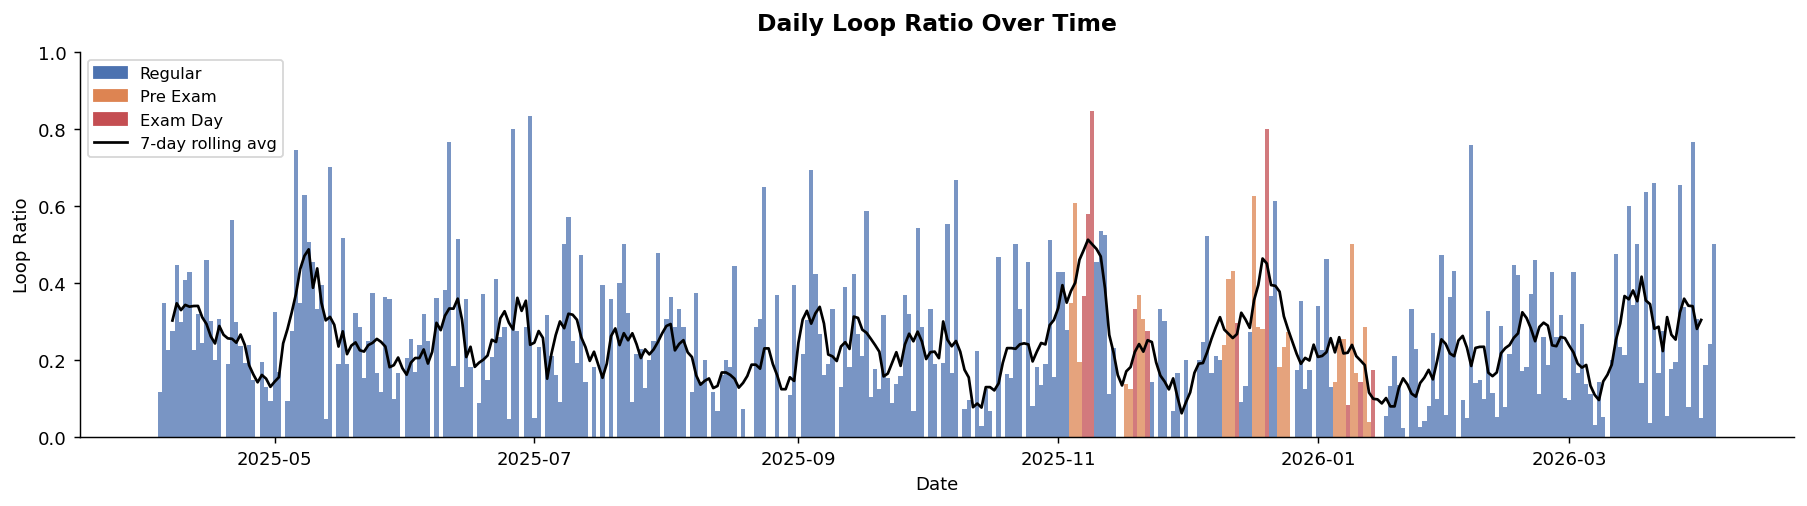

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

# Plot each period segment with its color
for _, row in daily.iterrows():
    ax.bar(row['date'], row['loop_ratio'], color=COLORS[row['period']], alpha=0.75, width=1)

# 7-day rolling average
daily['rolling'] = daily['loop_ratio'].rolling(7, center=True).mean()
ax.plot(daily['date'], daily['rolling'], color='black', linewidth=1.5, label='7-day rolling avg')

# Legend
patches = [mpatches.Patch(color=v, label=k.replace('_',' ').title()) for k, v in COLORS.items()]
patches.append(plt.Line2D([0],[0], color='black', linewidth=1.5, label='7-day rolling avg'))
ax.legend(handles=patches, loc='upper left', fontsize=9)

ax.set_title('Daily Loop Ratio Over Time', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Loop Ratio')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/01_loop_ratio_timeseries.png', bbox_inches='tight')
plt.show()

### 3.2 Loop Ratio by Period - Box Plot

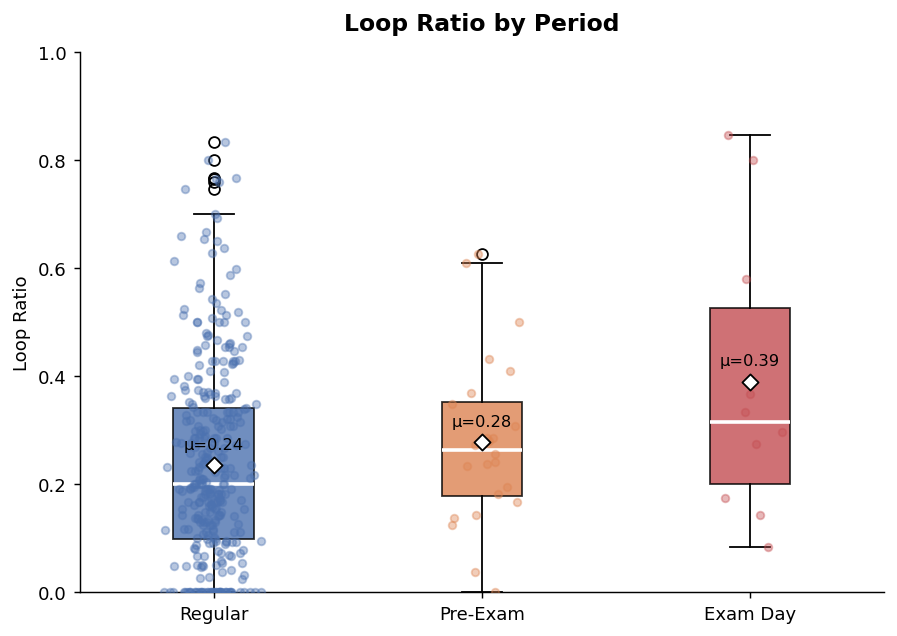

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

order = ['regular', 'pre_exam', 'exam_day']
labels = ['Regular', 'Pre-Exam', 'Exam Day']
data_by_period = [daily[daily['period'] == p]['loop_ratio'].values for p in order]

bp = ax.boxplot(data_by_period, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, period in zip(bp['boxes'], order):
    patch.set_facecolor(COLORS[period])
    patch.set_alpha(0.8)

# Overlay individual points
for i, (d, period) in enumerate(zip(data_by_period, order), 1):
    ax.scatter(np.random.normal(i, 0.07, len(d)), d,
               color=COLORS[period], alpha=0.4, s=18, zorder=3)

# Mean markers
for i, d in enumerate(data_by_period, 1):
    ax.scatter(i, np.mean(d), marker='D', color='white',
               edgecolors='black', s=40, zorder=5, linewidths=1)

ax.set_xticklabels(labels)
ax.set_title('Loop Ratio by Period', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Loop Ratio')
ax.set_ylim(0, 1)

# Annotate means
for i, d in enumerate(data_by_period, 1):
    ax.text(i, np.mean(d) + 0.03, f'μ={np.mean(d):.2f}',
            ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('figures/02_loop_ratio_boxplot.png', bbox_inches='tight')
plt.show()

### 3.3 Top 15 Most-Looped Tracks

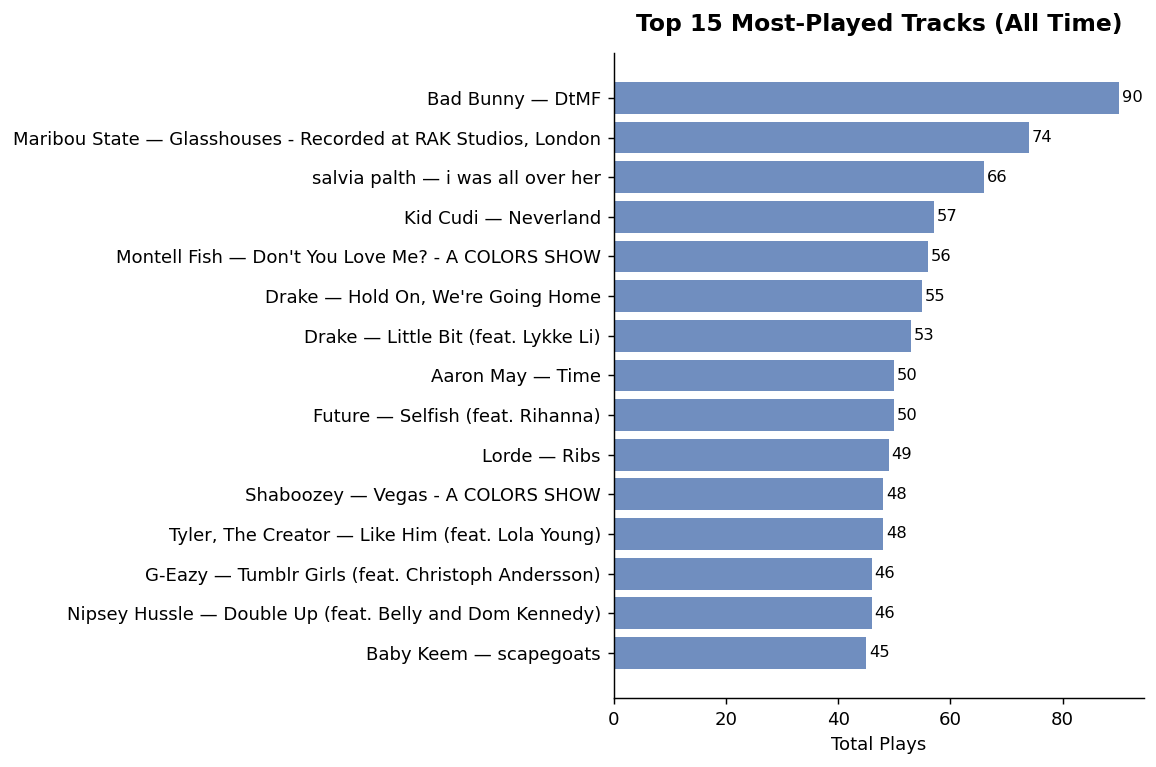

In [5]:
top_tracks = (
    df.groupby(['artistName', 'trackName'])
    .size()
    .reset_index(name='total_plays')
    .sort_values('total_plays', ascending=False)
    .head(15)
)
top_tracks['label'] = top_tracks['artistName'] + ' — ' + top_tracks['trackName']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_tracks['label'][::-1], top_tracks['total_plays'][::-1],
               color='#4C72B0', alpha=0.8)

for bar, val in zip(bars, top_tracks['total_plays'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('Top 15 Most-Played Tracks (All Time)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Plays')
plt.tight_layout()
plt.savefig('figures/03_top_tracks.png', bbox_inches='tight')
plt.show()

### 3.4 Hourly Listening Distribution by Period

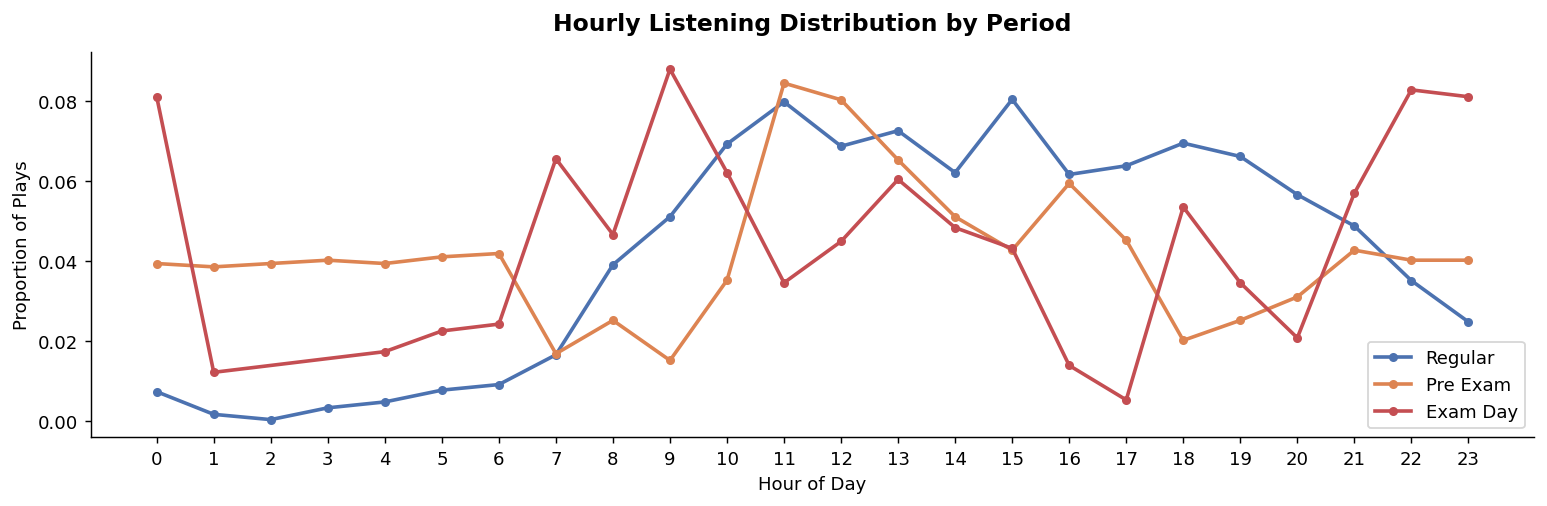

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

for period in ['regular', 'pre_exam', 'exam_day']:
    subset = df[df['period'] == period]
    hourly = subset.groupby('hour').size()
    hourly = hourly / hourly.sum()  # normalize to proportion
    ax.plot(hourly.index, hourly.values, label=period.replace('_',' ').title(),
            color=COLORS[period], linewidth=2, marker='o', markersize=4)

ax.set_title('Hourly Listening Distribution by Period', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Proportion of Plays')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('figures/04_hourly_distribution.png', bbox_inches='tight')
plt.show()

## 4. Hypothesis Testing

In [7]:
exam    = daily[daily['period'] == 'exam_day']['loop_ratio']
pre     = daily[daily['period'] == 'pre_exam']['loop_ratio']
regular = daily[daily['period'] == 'regular']['loop_ratio']

print('=== Descriptive Statistics ===')
print(f"{'Period':<12} {'n':>4} {'mean':>6} {'median':>8} {'std':>6}")
print('-' * 40)
for label, d in [('regular', regular), ('pre_exam', pre), ('exam_day', exam)]:
    print(f"{label:<12} {len(d):>4} {d.mean():>6.3f} {d.median():>8.3f} {d.std():>6.3f}")

print()
print('=== Normality Check (Shapiro-Wilk) ===')
for label, d in [('regular', regular), ('pre_exam', pre), ('exam_day', exam)]:
    stat, p = stats.shapiro(d)
    print(f"{label:<12} W={stat:.4f}  p={p:.4f}  {'→ NOT normal' if p < 0.05 else '→ normal'}")

print()
print('=== Mann-Whitney U Test (one-sided: exam > regular) ===')
stat1, p1 = stats.mannwhitneyu(exam, regular, alternative='greater')
stat2, p2 = stats.mannwhitneyu(pre, regular, alternative='greater')
print(f"Exam vs Regular:     U={stat1:.1f}  p={p1:.4f}  {'✓ Significant' if p1 < 0.05 else '✗ Not significant'} (α=0.05)")
print(f"Pre-exam vs Regular: U={stat2:.1f}  p={p2:.4f}  {'✓ Significant' if p2 < 0.05 else '✗ Not significant'} (α=0.05)")

print()
print('=== Effect Size (Cohen\'s d) ===')
def cohens_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)

d1 = cohens_d(exam, regular)
d2 = cohens_d(pre, regular)
print(f"Exam vs Regular:     d={d1:.3f}  → {'large' if abs(d1)>=0.8 else 'medium' if abs(d1)>=0.5 else 'small'} effect")
print(f"Pre-exam vs Regular: d={d2:.3f}  → {'large' if abs(d2)>=0.8 else 'medium' if abs(d2)>=0.5 else 'small'} effect")

=== Descriptive Statistics ===
Period          n   mean   median    std
----------------------------------------
regular       330  0.236    0.200  0.182
pre_exam       24  0.278    0.264  0.157
exam_day       10  0.390    0.315  0.266

=== Normality Check (Shapiro-Wilk) ===
regular      W=0.9400  p=0.0000  → NOT normal
pre_exam     W=0.9586  p=0.4114  → normal
exam_day     W=0.8877  p=0.1596  → normal

=== Mann-Whitney U Test (one-sided: exam > regular) ===
Exam vs Regular:     U=2225.0  p=0.0302  ✓ Significant (α=0.05)
Pre-exam vs Regular: U=4657.0  p=0.0749  ✗ Not significant (α=0.05)

=== Effect Size (Cohen's d) ===
Exam vs Regular:     d=0.674  → medium effect
Pre-exam vs Regular: d=0.248  → small effect


## 5. Summary

| Comparison | Mean (exam) | Mean (regular) | U-stat | p-value | Cohen's d |
|---|---|---|---|---|---|
| Exam Day vs Regular | 0.390 | 0.236 | 2225.0 | **0.030** | 0.674 |
| Pre-Exam vs Regular | 0.278 | 0.236 | 4657.0 | 0.075 | 0.248 |

**Interpretation:** The Mann-Whitney U test reveals a statistically significant difference in daily loop ratio between exam days and regular days (p = 0.030, α = 0.05). The effect size is medium-to-large (d = 0.674). The pre-exam period shows a trend in the same direction but does not reach significance (p = 0.075), suggesting the loop behavior peaks on the exam day itself rather than building gradually in the days before.

**Limitation:** The exam-day sample is small (n = 10), which reduces statistical power. Results should be interpreted with caution.